In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

## Structure Check

### (1) Raw Dataset Overview

In [2]:
df = pd.read_csv('dataset/raw.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


### (2) Columns Indices

In [3]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### (3) Number of row and column

In [4]:
df.shape

(303, 14)

### (4) Check for NULL data and data types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### (5) Duplicate rows and explicit missing-value count
The Cleveland subset should report 0 missing values (per README) and surface any duplicate records.

In [6]:
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Total missing  : {df.isna().sum().sum()}")
df.isna().sum()

Duplicate rows : 0
Total missing  : 0


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Target Variable distribution
0: no disease
1: diseased

In [7]:
df['target'].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

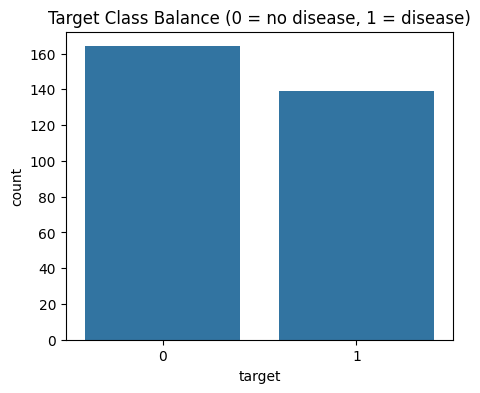

In [8]:
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=df)
plt.title("Target Class Balance (0 = no disease, 1 = disease)")
plt.xlabel("target")
plt.show()

## Feature Distribution

In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


### (1) Histogram

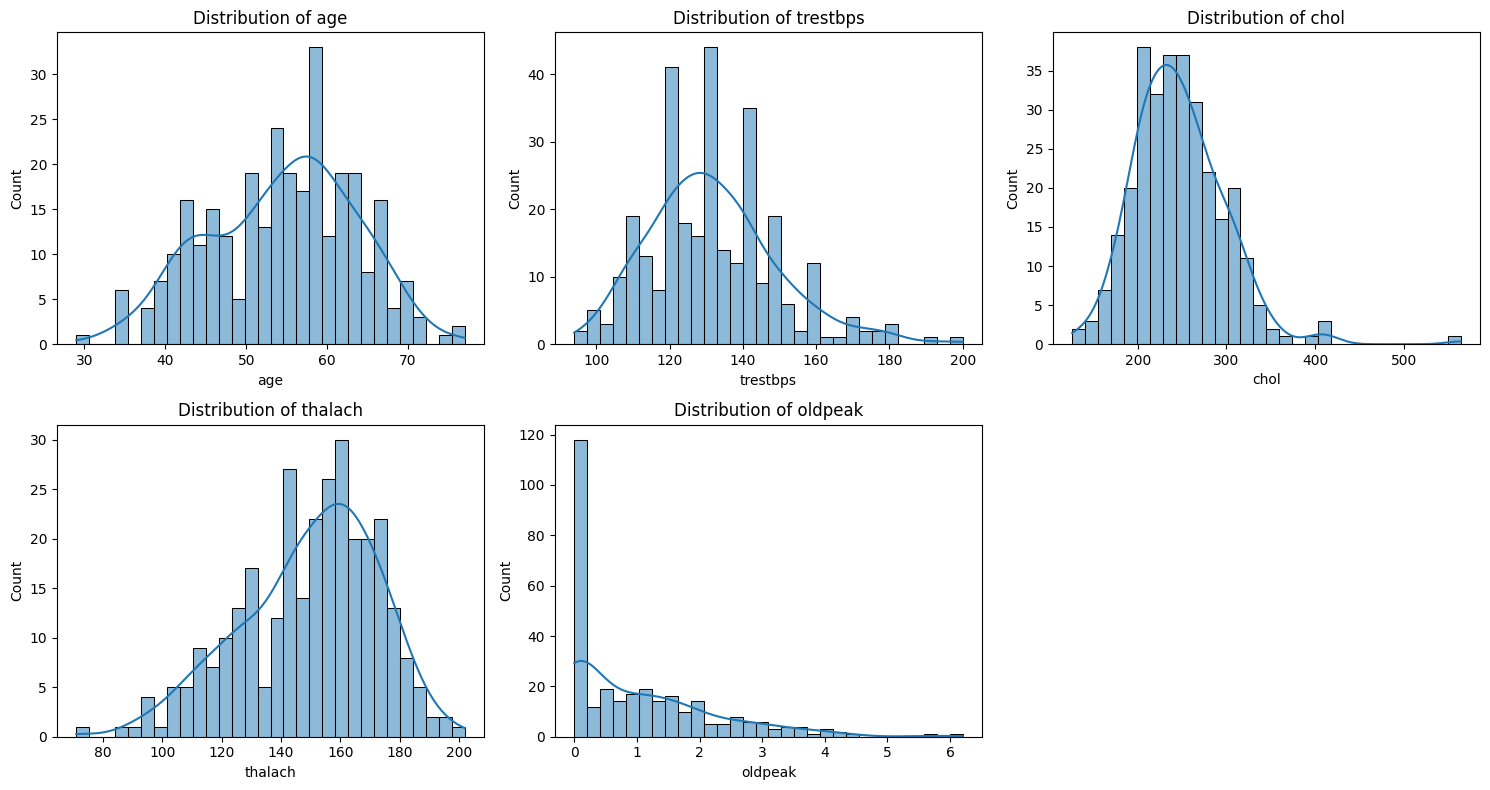

In [10]:
continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(15, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### (2) Boxplots for Outlier detection

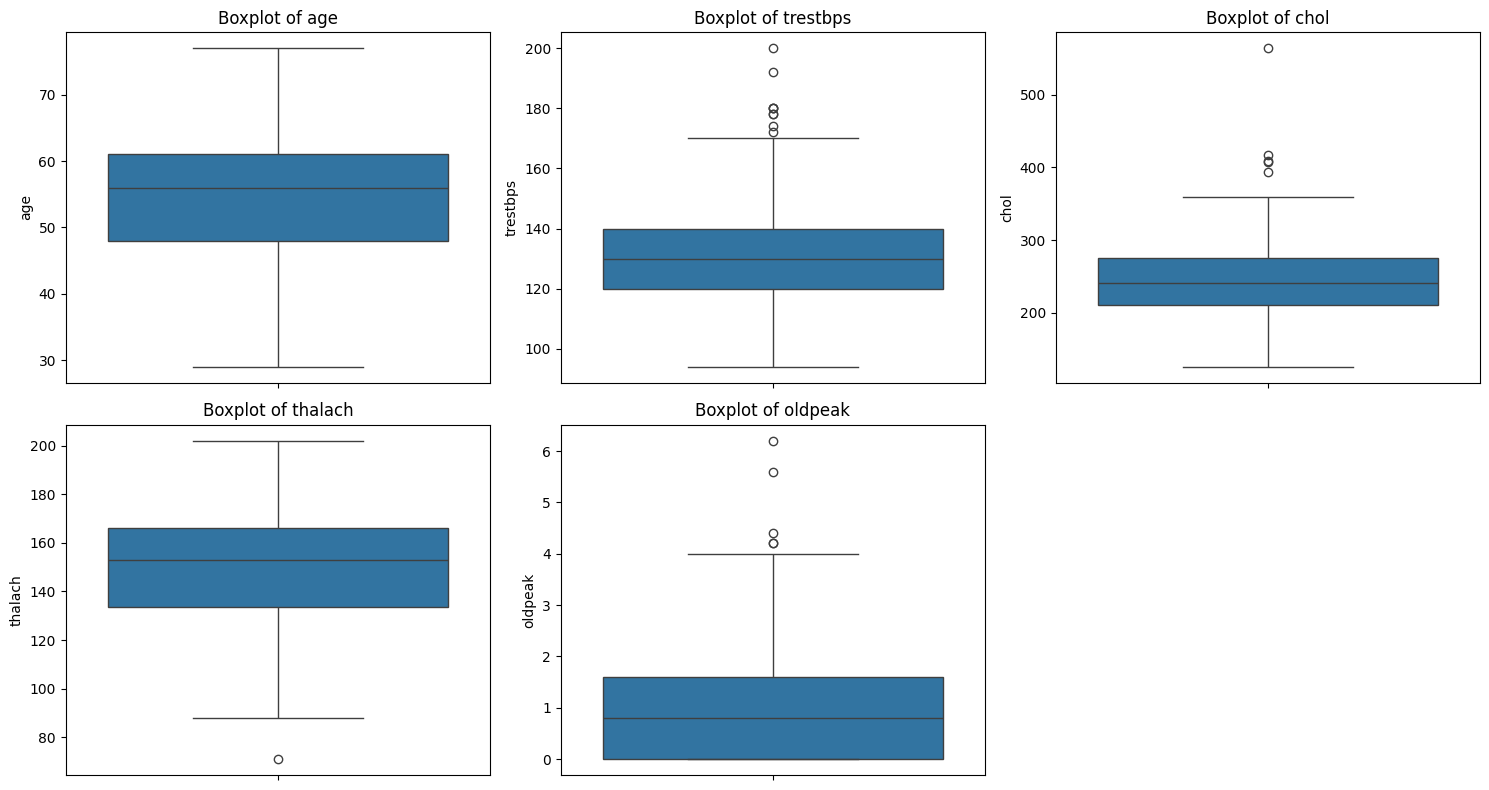

In [11]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

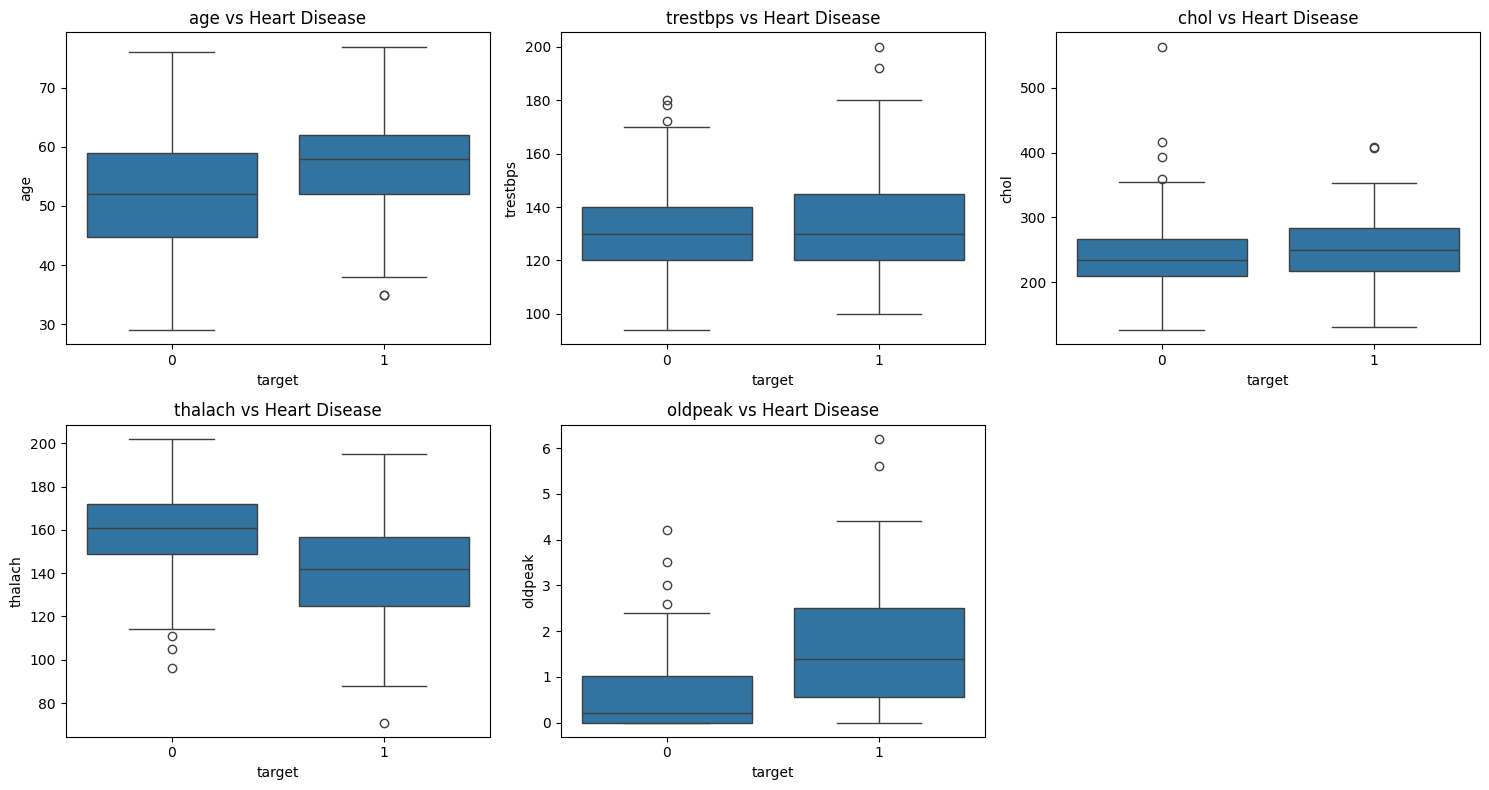

In [12]:
target_col = "target"  # usually 0/1

plt.figure(figsize=(15, 8))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} vs Heart Disease")

plt.tight_layout()
plt.show()

## Relationship

### (1) Correlation Heatmap

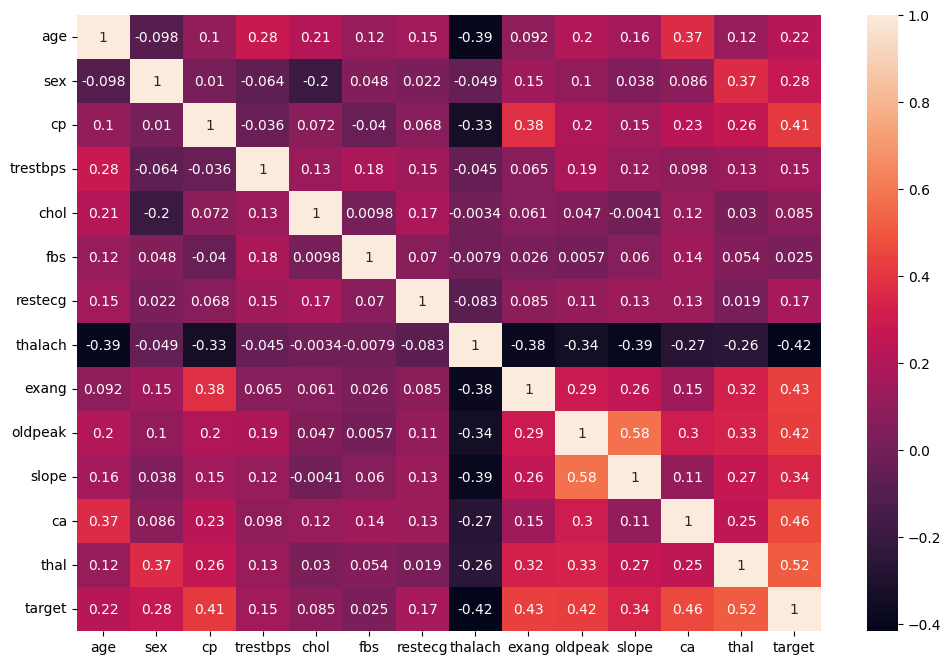

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr() , annot=True)
plt.show()

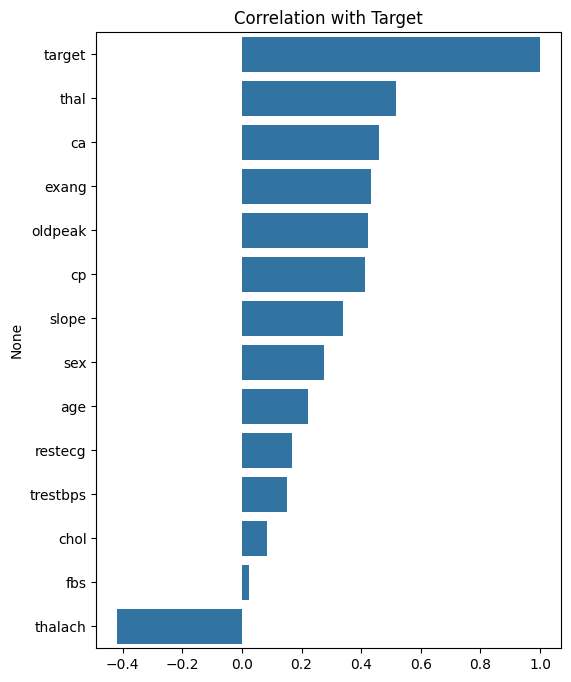

In [14]:
plt.figure(figsize=(6, 8))

target_corr = df.corr(numeric_only=True)[target_col].sort_values(ascending=False)

sns.barplot(x=target_corr.values, y=target_corr.index)

plt.title("Correlation with Target")
plt.show()

### (2)Groupby Means

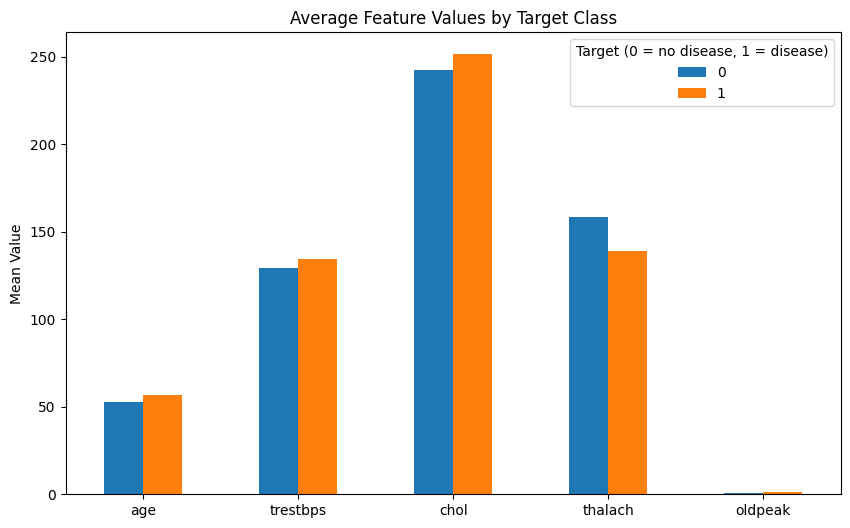

In [15]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

group_means = df.groupby(target_col)[numeric_features].mean()
group_means.T.plot(kind="bar", figsize=(10, 6))

plt.title("Average Feature Values by Target Class")
plt.ylabel("Mean Value")
plt.xticks(rotation=0)
plt.legend(title="Target (0 = no disease, 1 = disease)")
plt.show()

### (3)Categorical Feature vs Target

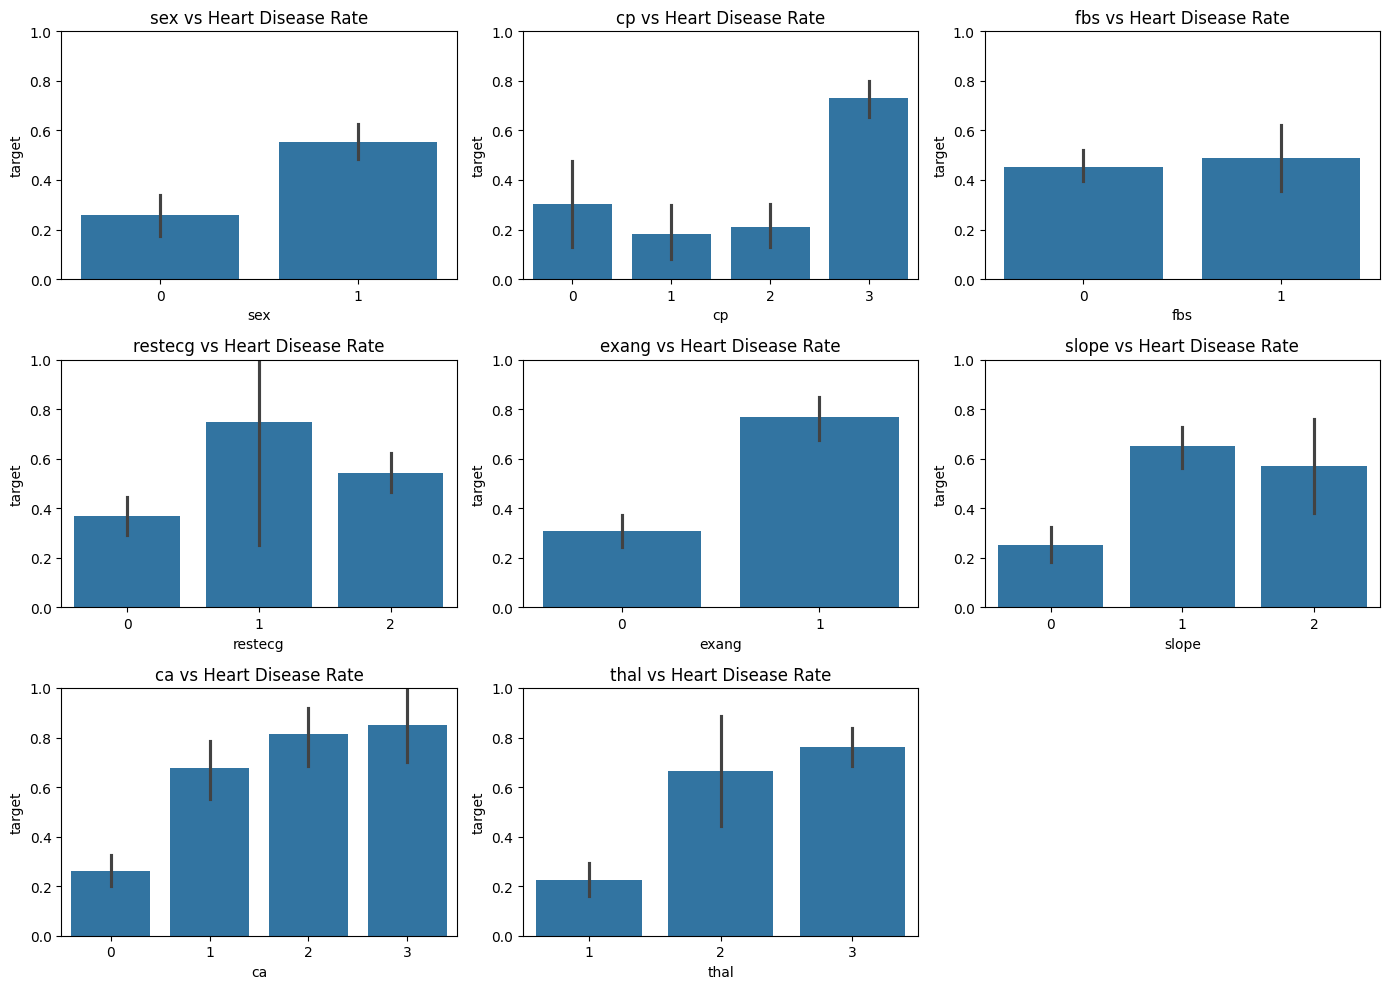

In [16]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    
    sns.barplot(
        x=col,
        y=target_col,
        data=df,
        estimator=lambda x: sum(x) / len(x)
    )
    
    plt.title(f"{col} vs Heart Disease Rate")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Feature Check

## Feature Dictionary

Source: [UCI Heart Disease — Cleveland subset](https://archive.ics.uci.edu/dataset/45/heart+disease)

| Feature | Type | Description |
|---|---|---|
| age | continuous | Age (years) |
| sex | categorical | 0 = female, 1 = male |
| cp | categorical | Chest pain: 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic |
| trestbps | continuous | Resting blood pressure at admission (mm Hg) |
| chol | continuous | Serum cholesterol (mg/dl) |
| fbs | categorical | Fasting blood sugar: 0 = ≤120 mg/dl, 1 = >120 mg/dl |
| restecg | categorical | Resting ECG: 0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy (Estes' criteria) |
| thalach | continuous | Maximum heart rate achieved (bpm) |
| exang | categorical | Exercise-induced angina: 0 = no, 1 = yes |
| oldpeak | continuous | ST depression induced by exercise relative to rest |
| slope | categorical | Slope of peak exercise ST segment: 0 = upsloping, 1 = flat, 2 = downsloping |
| ca | categorical | Number of major vessels colored by fluoroscopy (0–3) |
| thal | categorical | Thalassemia: 1 = normal, 2 = fixed defect, 3 = reversible defect |
| target | target | 0 = no disease, 1 = disease |